# <p style="font-size:100%; text-align:left; color:#444444;">Exploratory Data Analysis - Avian Influenza (Bird Flu)</p>

![Word Cloud](img/Avian-influenza-word-cloud.jpeg "Word Cloud")

---
# <p style="font-size:100%; text-align:left; color:#444444;">Contents:</p>

* [1. Introduction](#1)
    * [1.1 Data Description](#1.1)
    * [1.2 Libraries](#1.2)
    * [1.3 Loading Dataset](#1.3)
* [2. Preprocessing & Feature Engineering](#2)
    * [2.1 Target variable distribution](#2.1)
    * [2.2 Missing values](#2.2)
    * [2.3 Exploratory Analysis](#2.3)
    * [2.4 Features Importance](#2.4)
    * [2.5 Data transformation and normalization](#2.5)
* [3. Models](#3)
    * [3.1 LightGBM](#3.1)
    * [3.2 XGBoost](#3.2)
    * [3.3 Random Search for Hyper-Parameter Optimization](#3.3)
    * [3.4 LightGBM Tuned](#3.4)
* [4. Evaluation](#4)
    * [4.1 Normalized Gini Coefficient](#4.1)
    * [4.2 LightGBM Evaluation](#4.2)
    * [4.3 XGBoost Evaluation](#4.3)
    * [4.4 LightGBM Tuned Evaluation](#4.4)
    * [4.5 ROC AUC](#4.5)
* [5. Conclusion](#5)

<a id="1"></a>
# <p style="font-size:100%; text-align:left; color:#444444;">1- Introduction</p>

Avian influenza or **"Bird Flu"** is a contagious and often fatal viral disease of birds. Wild birds, particularly wild migratory water birds are considered to be the main reservoir of avian influenza viruses. There is a constant risk of avian influenza being introduced into Ireland from wild birds particularly from November onwards each year as this is when migratory birds arrive and congregate on wetlands, mixing with resident species. The attached file is a data set of the locations of bird species captured in Ireland from 1980 to 2020 and wild birds that are targeted for the H5N1 strain of avian flu.

## Questions

1. Which wild bird species were most affected by the avian flu in Ireland?
1. What locations have registered the highest number of wild birds with avian flu?
1. The identification of wild birds with avian flu has been increasing or decreasing throughout the years?
1. What month has the highest number of infected birds?
1. How geographic distributed is the capturing of infected wild birds? (Heatmap and Map count)

## Data Viz

1. Heatmap for most affected areas
2. Map with count of infected birds
3. Line chart with count every year
4. Top 10 most affected species
5. Dashboard with maps and graphs
6. Deployment of ML (selecting parent species, species and location)

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

%matplotlib inline
matplotlib.style.use("ggplot")

import time
import warnings
warnings.simplefilter('ignore', FutureWarning)

In [2]:
from platform import python_version
print('Python version:', python_version())

Python version: 3.8.5


In [3]:
%reload_ext watermark
%watermark -a "Leandro Pessini" --iversions

Author: Leandro Pessini

pandas    : 1.1.3
numpy     : 1.19.2
json      : 2.0.9
matplotlib: 3.3.2
seaborn   : 0.11.1



In [4]:
bird_flu = pd.read_csv("./data/bird-flu.csv", encoding='latin-1')

In [5]:
bird_flu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16304 entries, 0 to 16303
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Scientific_Name       16304 non-null  object 
 1   Common_Name           16304 non-null  object 
 2   Date                  16304 non-null  object 
 3   Year                  16304 non-null  int64  
 4   Month                 16304 non-null  int64  
 5   Day                   16304 non-null  int64  
 6   Time                  16304 non-null  int64  
 7   Country               16304 non-null  object 
 8   Country_State_County  16304 non-null  object 
 9   State                 16304 non-null  object 
 10  County                16175 non-null  object 
 11  Locality              16304 non-null  object 
 12  Latitude              16304 non-null  float64
 13  Longitude             16304 non-null  float64
 14  Parent_Species        16304 non-null  object 
 15  target_H5_HPAI     

**The dataset does not have missing data.**

In [6]:
bird_flu.head()

,Scientific_Name,Common_Name,Date,Year,Month,Day,Time,Country,Country_State_County,State,County,Locality,Latitude,Longitude,Parent_Species,target_H5_HPAI
0,Acrocephalus scirpaceus,Eurasian Reed Warbler,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Acrocephalus scirpaceus,0
1,Acrocephalus scirpaceus,Eurasian Reed Warbler,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Acrocephalus scirpaceus,0
2,Limosa haemastica,Hudsonian Godwit,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Limosa haemastica,0
3,Limosa haemastica,Hudsonian Godwit,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Limosa haemastica,0
4,Limosa haemastica,Hudsonian Godwit,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Limosa haemastica,0


Text(0.5, 1.0, 'Bird flu Distribution')

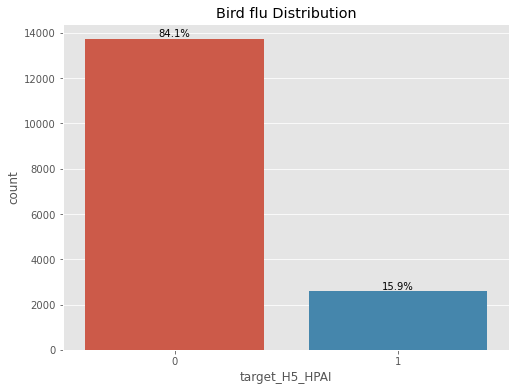

In [7]:
y = bird_flu.target_H5_HPAI
fig = plt.figure(figsize=(8, 6))
ax = sns.countplot(y,label="Count")

total_size = len(bird_flu)

# Display the target value ratio at the top of the bar
for patch in ax.patches:
    height = patch.get_height()
    width = patch.get_width()
    left_coord = patch.get_x()
    percent = height/total_size*100

    ax.text(x=left_coord + width/2.0, 
            y=height + 100,
            s='{:1.1f}%'.format(percent),
            ha='center')

ax.set_title('Bird flu Distribution')

In [8]:
grouped_scientific_name = pd.DataFrame({'count' : bird_flu.groupby(['Scientific_Name'])['Scientific_Name'].size()}).reset_index()
grouped_common_name = pd.DataFrame({'count' : bird_flu.groupby(['Common_Name'])['Common_Name'].size()}).reset_index()
grouped_parent_species = pd.DataFrame({'count' : bird_flu.groupby(['Parent_Species'])['Parent_Species'].size()}).reset_index()

In [9]:
len(grouped_scientific_name) == len(grouped_common_name)

True

Asserting that scientific name and common name have the same size.

In [10]:
print("There are {} wild bird species present and {} parent species.".format(len(grouped_common_name), len(grouped_parent_species)))

There are 410 wild bird species present and 338 parent species.


In [11]:
pd.DataFrame({'count' : bird_flu.groupby(['County'])['County'].size()}).reset_index()

,County,count
0,Carlow,13
1,Cavan,10
2,Clare,989
3,Cork,1275
4,Donegal,559
5,Dublin,5191
6,Galway,2502
7,Kerry,1408
8,Kildare,62
9,Kilkenny,94


In [12]:
top_10_infected_locations = pd.DataFrame({'count' : bird_flu[bird_flu['target_H5_HPAI'] == 1].groupby(['Locality']).size()}).sort_values('count', ascending=False).head(15)

#grouped.filter(lambda x: x['B'].mean() > 3.)
top_10_infected_locations

,count
Locality,
St. Stephen's Green,130
Rogerstown Estuary--Turvey Hide,108
Lough Atalia,100
Rogerstown Estuary--North Hide,85
Swords Estuary--Broadmeadows,81
Booterstown Marsh NR,64
East Coast NR,60
North Bull Island NR--general area,59
Tolka Valley Park,50


In [13]:
infected_month = pd.DataFrame({'count' : bird_flu[bird_flu['target_H5_HPAI'] == 1].groupby(['Month']).size()}).sort_values('Month', ascending=True).head(15)

infected_month

,count
Month,
1,96
2,112
3,215
4,106
5,226
6,389
7,173
8,423
9,274


In [14]:
bird_flu[bird_flu['target_H5_HPAI'] == 1]

,Scientific_Name,Common_Name,Date,Year,Month,Day,Time,Country,Country_State_County,State,County,Locality,Latitude,Longitude,Parent_Species,target_H5_HPAI
6,Larus canus,Mew Gull,16/08/2014,2014,8,16,930,Ireland,IE-M-KY,Munster,Kerry,Ring of Kerry.,52.0018,-10.1239,Larus canus,1
12,Ardea cinerea,Gray Heron,23/06/2005,2005,6,23,700,Ireland,IE-M-CE,Munster,Clare,Callagan's B & B,53.1336,-9.0747,Ardea cinerea,1
14,Cygnus olor,Mute Swan,23/06/2005,2005,6,23,900,Ireland,IE-M-CE,Munster,Clare,Ballyvaughan Harbour,53.1192,-9.1532,Cygnus olor,1
15,Ardea cinerea,Gray Heron,23/06/2005,2005,6,23,900,Ireland,IE-M-CE,Munster,Clare,Ballyvaughan Harbour,53.1192,-9.1532,Ardea cinerea,1
16,Cygnus olor,Mute Swan,23/06/2005,2005,6,23,900,Ireland,IE-M-CE,Munster,Clare,Ballyvaughan Harbour,53.1192,-9.1532,Cygnus olor,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16276,Anas platyrhynchos,Mallard,26/01/2020,2020,1,26,1305,Ireland,IE-L-DN,Leinster,Dublin,Tymon Park,53.3008,-6.3426,Anas platyrhynchos,1
16288,Tadorna tadorna,Common Shelduck,27/01/2020,2020,1,27,1406,Ireland,IE-L-DN,Leinster,Dublin,North Bull Island NR--causeway,53.3726,-6.1591,Tadorna tadorna,1
16290,Anas acuta,Northern Pintail,27/01/2020,2020,1,27,1406,Ireland,IE-L-DN,Leinster,Dublin,North Bull Island NR--causeway,53.3726,-6.1591,Anas acuta,1
16291,Anas acuta,Northern Pintail,27/01/2020,2020,1,27,1406,Ireland,IE-L-DN,Leinster,Dublin,North Bull Island NR--causeway,53.3726,-6.1591,Anas acuta,1


In [15]:
bird_flu.groupby('Date')['target_H5_HPAI'].agg(['count'])

,count
Date,
01/01/2014,2
01/01/2017,1
01/01/2018,1
01/01/2019,5
01/01/2020,10
...,...
31/10/2019,16
31/12/2009,12
31/12/2015,21


In [18]:
import geopandas as gpd

In [19]:
boundaries = gpd.read_file('data/boundaries/Census2011_NUTS3_generalised20m.shp')

In [21]:
type(boundaries)

geopandas.geodataframe.GeoDataFrame

In [22]:
boundaries.head()

,NUTS1,NUTS1NAME,NUTS2,NUTS2NAME,NUTS3,NUTS3NAME,GEOGID,MALE2011,FEMALE2011,TOTAL2011,PPOCC2011,UNOCC2011,HS2011,VACANT2011,PCVAC2011,TOTAL_AREA,LAND_AREA,CREATEDATE,geometry
0,IE0,Ireland,IE02,Southern and Eastern,IE024,South-East (IE),R6,247836.0,249742.0,497578.0,181056.0,39805.0,220861.0,35569.0,16.1,9456.954384,9400.252112,27-03-2012,"MULTIPOLYGON (((226795.519 90273.986, 226800.6..."
1,IE0,Ireland,IE02,Southern and Eastern,IE025,South-West (IE),R7,330099.0,334435.0,664534.0,242578.0,59844.0,302422.0,53048.0,17.5,12311.731981,12120.366266,27-03-2012,"MULTIPOLYGON (((18146.051 95109.853, 18150.159..."
2,IE0,Ireland,IE01,"Border,Midland and Western",IE011,Border,R1,257319.0,257572.0,514891.0,186518.0,58525.0,245043.0,53757.0,21.9,12342.702289,12010.959427,27-03-2012,"MULTIPOLYGON (((306570.430 309491.953, 306521...."
3,IE0,Ireland,IE01,"Border,Midland and Western",IE012,Midland,R5,141449.0,140961.0,282410.0,99971.0,18925.0,118896.0,16703.0,14.0,6651.424612,6509.647274,27-03-2012,"POLYGON ((223420.563 298777.860, 223514.240 29..."
4,IE0,Ireland,IE01,"Border,Midland and Western",IE013,West,R8,222531.0,222825.0,445356.0,161288.0,47266.0,208554.0,42383.0,20.3,14289.119880,13641.860486,27-03-2012,"MULTIPOLYGON (((48596.741 265596.221, 48612.89..."


In [24]:
!pip install descartes

<AxesSubplot:>

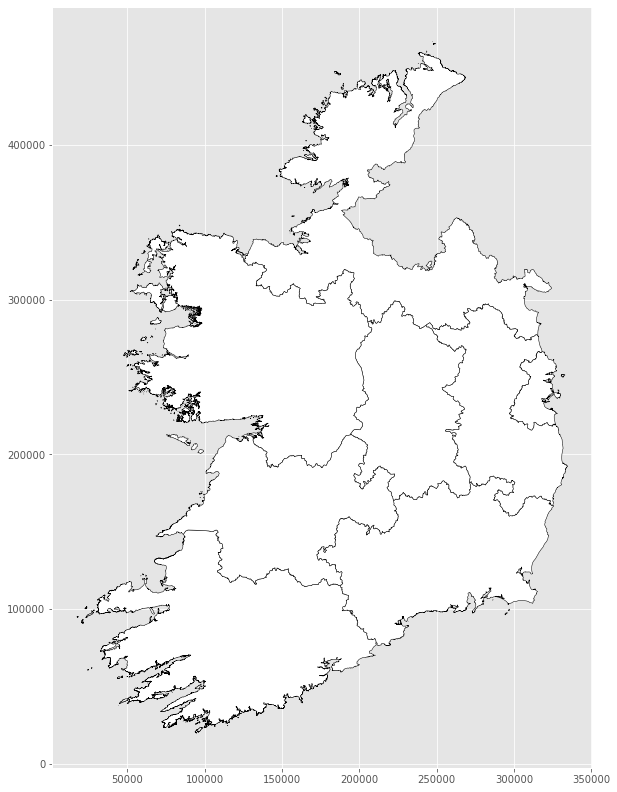

In [31]:
boundaries.plot(figsize=(16,14), facecolor='white', edgecolor='black')